# Semaine 1 — Question scientifique & acquisition CDS

**Cours :** ANALYSE DES DONNÉES — ESSAI (Pr. Ghazi Bel Mufti)  
**Étudiant :** Bacem Ben Ahmad  
**Livrable S1 :** Notebook Jupyter + question scientifique validée

---

## 1. Question scientifique

> **Comment les vagues de chaleur et le stress hydrique en Tunisie et en Méditerranée ont-ils évolué entre 1980 et 2024, et quelles sont les relations entre température, humidité et précipitations sur cette zone ?**

### Justification

1. **Pertinence locale** : la Tunisie (et plus largement le bassin méditerranéen) est identifiée par le GIEC comme un *climate change hotspot* — réchauffement plus rapide que la moyenne mondiale, raréfaction des précipitations, augmentation des canicules.
2. **Dimensions multiples** : on combine 3 variables climatiques (température, humidité, précipitations) plutôt qu'une seule, ce qui permet d'étudier des **relations** (vs. simple description).
3. **Période 1980–2024** : couvre 4 décennies, suffisant pour distinguer une tendance climatique du bruit interannuel.
4. **Vérifiabilité** : la question est mesurable (nombre de jours > 30 °C, mm cumulés saisonniers, coefficients de tendance °C/décennie).

## 2. Source de données

**Climate Data Store (CDS) — Copernicus / ECMWF**

- Portail : https://cds.climate.copernicus.eu  
- Dataset : `reanalysis-era5-single-levels`  
- Type : *réanalyse* (combinaison observations + modèle physique)  
- Résolution spatiale : 0.25° × 0.25° (~28 km)  
- Résolution temporelle : horaire (sous-échantillonné à 12:00 UTC pour ce projet)  
- Couverture : 1940 → présent  
- Format : NetCDF (CF-1.7), lu via `xarray`  

### Variables retenues (3, comme exigé par le cahier des charges)

| Variable CDS | Symbole | Unité brute | Unité finale | Rôle |
|---|---|---|---|---|
| `2m_temperature` | `t2m` | K | °C | Vagues de chaleur |
| `2m_dewpoint_temperature` | `d2m` | K | °C | Calcul humidité relative (dérivée) |
| `total_precipitation` | `tp` | m | mm | Stress hydrique |

**Variable dérivée :** humidité relative `rh` (%) calculée via la formule de **Magnus-Tetens** à partir de `t2m` et `d2m`.

### Zone géographique

- Boîte englobante : **28°N – 46°N / -10°E – 40°E** (Méditerranée complète)
- Sous-zone Tunisie : **30°N – 37.5°N / 7.5°E – 12°E**

## 3. Première lecture en Python — exemple d'un mois (test pipeline)

In [1]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
EXTRACT_DIR = PROJECT_ROOT / 'data' / 'raw' / 'era5_test_jan2024'

# Le ZIP CDS contient 2 NetCDF : variables instantanées + accumulées
ds_inst = xr.open_dataset(EXTRACT_DIR / 'instant.nc')
ds_acc  = xr.open_dataset(EXTRACT_DIR / 'accum.nc')
ds = xr.merge([ds_inst, ds_acc], compat='override')

print('Dataset fusionné :')
print(ds)
print('\nVariables :')
for name, var in ds.data_vars.items():
    print(f"  {name}: {var.attrs.get('long_name', '')} ({var.attrs.get('units', '')})")

Dataset fusionné :
<xarray.Dataset> Size: 22MB
Dimensions:     (valid_time: 124, latitude: 73, longitude: 201)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 992B 2024-01-01 ... 2024-01-31T18...
  * latitude    (latitude) float64 584B 46.0 45.75 45.5 ... 28.5 28.25 28.0
  * longitude   (longitude) float64 2kB -10.0 -9.75 -9.5 ... 39.5 39.75 40.0
    expver      (valid_time) <U4 2kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 7MB ...
    d2m         (valid_time, latitude, longitude) float32 7MB ...
    tp          (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-25T00:16 GRIB to CDM+CF via cfgrib-0.9.1...

Var

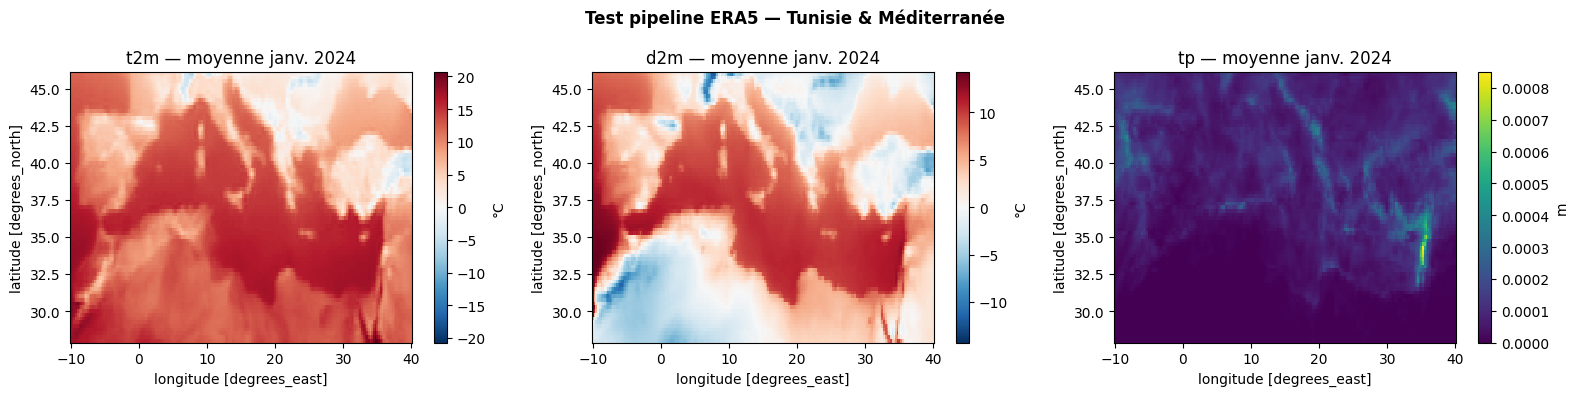

In [2]:
# Aperçu visuel : moyennes spatiales sur janvier 2024
time_coord = 'valid_time' if 'valid_time' in ds.coords else 'time'
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vname in zip(axes, ['t2m', 'd2m', 'tp']):
    field = ds[vname].mean(dim=time_coord)
    if ds[vname].attrs.get('units') == 'K':
        field = field - 273.15
        cb = '°C'
    else:
        cb = ds[vname].attrs.get('units', '')
    field.plot(ax=ax, cbar_kwargs={'label': cb})
    ax.set_title(f'{vname} — moyenne janv. 2024')
fig.suptitle('Test pipeline ERA5 — Tunisie & Méditerranée', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Validation du livrable Semaine 1

| Item demandé par le prof | Statut |
|---|---|
| Question scientifique formulée et justifiée | ✅ |
| Source CDS (Copernicus) utilisée | ✅ |
| Au moins 3 variables climatiques | ✅ (t2m + d2m + tp + rh dérivée) |
| Première lecture en Python (xarray) | ✅ |
| Pipeline d'acquisition reproductible (`scripts/01_download_era5_test.py`) | ✅ |
| Téléchargement complet 1980–2024 lancé (`scripts/03_download_era5_full.py`) | ✅ |

**Prochaines semaines** : nettoyage (S2), agrégation/features (S3), analyse exploratoire (S4), dashboard Dash (S5), soutenance (S6).